### [Boosting Accuracy with Polynomial Features in XGBoost](https://python.plainenglish.io/boosting-accuracy-with-polynomial-features-in-xgboost-f5cab602aaca)

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Select baseline features
X = df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
y = df['Survived']

# Handle missing values
X['Age'].fillna(X['Age'].median(), inplace=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline XGBoost model
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred))

Baseline Accuracy: 0.6927374301675978


In [3]:
from sklearn.preprocessing import PolynomialFeatures

# Polynomial transformation (degree=2)
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X)

# Get new feature names
poly_features = poly.get_feature_names_out(X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=poly_features)

display(X_poly_df.head())

,Pclass,Age,SibSp,Parch,Fare,Pclass^2,Pclass Age,Pclass SibSp,Pclass Parch,Pclass Fare,Age^2,Age SibSp,Age Parch,Age Fare,SibSp^2,SibSp Parch,SibSp Fare,Parch^2,Parch Fare,Fare^2
0,3.0,22.0,1.0,0.0,7.2500,9.0,66.0,3.0,0.0,21.7500,484.0,22.0,0.0,159.5000,1.0,0.0,7.2500,0.0,0.0,52.562500
1,1.0,38.0,1.0,0.0,71.2833,1.0,38.0,1.0,0.0,71.2833,1444.0,38.0,0.0,2708.7654,1.0,0.0,71.2833,0.0,0.0,5081.308859
2,3.0,26.0,0.0,0.0,7.9250,9.0,78.0,0.0,0.0,23.7750,676.0,0.0,0.0,206.0500,0.0,0.0,0.0000,0.0,0.0,62.805625
3,1.0,35.0,1.0,0.0,53.1000,1.0,35.0,1.0,0.0,53.1000,1225.0,35.0,0.0,1858.5000,1.0,0.0,53.1000,0.0,0.0,2819.610000
4,3.0,35.0,0.0,0.0,8.0500,9.0,105.0,0.0,0.0,24.1500,1225.0,0.0,0.0,281.7500,0.0,0.0,0.0000,0.0,0.0,64.802500


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_poly_df, y, test_size=0.2, random_state=42)

model_poly = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model_poly.fit(X_train, y_train)

y_pred_poly = model_poly.predict(X_test)
print("Accuracy with Polynomial Features:", accuracy_score(y_test, y_pred_poly))

Accuracy with Polynomial Features: 0.7206703910614525


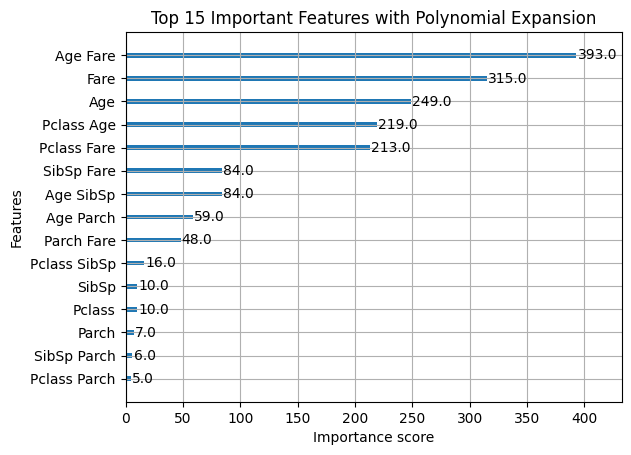

In [5]:
import matplotlib.pyplot as plt

xgb.plot_importance(model_poly, max_num_features=15)
plt.title("Top 15 Important Features with Polynomial Expansion")
plt.show()